# 10. Прогон по датасету

| вход | выход |
|---|---|
| все файлы датасета и один набор параметров | таблица метрик и галерея результатов |

Этапные блокноты показывают один кадр во всех подробностях, а этот показывает весь датасет по
верхам. Он нужен, чтобы находить кадры, на которых пайплайн ведет себя не так, как на том, где
подбирались параметры.

На что смотреть в таблице:

- **шпор до и шпор после** это доля шпор среди ребер графа. Высокое значение до замыкания означает
  разорванный контур, а если после замыкания оно не упало, значит ядро мало для этого кадра.
- **пустот выросло** это индикатор слипания: замыкание начало сшивать соседние параллельные линии.
- **итог кусков** сильно больше единицы означает, что деталь распалась, а ноль оставленных компонент
  означает, что правило съело все.
- **граница t** это первая граница классов толщины. Если она близка к толщине контура, часть контура
  уедет в младший класс.

In [1]:
import time
from pathlib import Path

from stage_metrics import PipelineRow, build_dataset_table, measure_pipeline_row
from visualization import show_before_after_list, shrink_mask_for_preview

from draftslice.common_types import Mask
from draftslice.image_preparation import load_bgr_image
from draftslice.pipeline import run_pipeline
from draftslice.pipeline_parameters import PipelineParameters
from draftslice.text_detection import TextProbabilityDetector

DATASET_FOLDER = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
MODEL_PATH = Path("../models/PP-OCRv5_server_det_infer.onnx")

parameters = PipelineParameters()
detector = TextProbabilityDetector(MODEL_PATH)
source_files: list[Path] = sorted(DATASET_FOLDER.glob("*.jpg"))
print(f"файлов: {len(source_files)}")

файлов: 21


## Прогон

Кадры считаются последовательно, ошибка на одном файле не останавливает прогон: имя такого файла
попадает в список падений.

In [2]:
rows: list[PipelineRow] = []
before_previews: dict[str, Mask] = {}
after_previews: dict[str, Mask] = {}
failures: dict[str, str] = {}

for source_path in source_files:
    started = time.time()
    try:
        image = load_bgr_image(source_path)
        artifacts = run_pipeline(image, detector, parameters)
    except Exception as error:
        failures[source_path.stem] = f"{type(error).__name__}: {error}"
        print(f"{source_path.stem}: падение, {type(error).__name__}")
        continue

    rows.append(measure_pipeline_row(source_path.stem, max(image.shape[:2]), artifacts))
    print(f"{source_path.stem}: {time.time() - started:.1f} c | компонент {len(artifacts.features)}")
    before_previews[source_path.stem] = shrink_mask_for_preview(artifacts.strokes_mask)
    after_previews[source_path.stem] = shrink_mask_for_preview(artifacts.part_mask)
    del artifacts, image

print(f"\nпосчитано {len(rows)} | падений {len(failures)}")

1: 3.0 c | компонент 10
10: 2.0 c | компонент 38
11: 2.4 c | компонент 18
12: 2.4 c | компонент 19
13: 12.5 c | компонент 11
14: 13.3 c | компонент 48
15: 2.3 c | компонент 21
16: 2.2 c | компонент 26
17: 1.8 c | компонент 26
18: 6.2 c | компонент 33
19: 1.9 c | компонент 36
2: 1.8 c | компонент 8
20: 35.4 c | компонент 38
21: 36.0 c | компонент 33
3: 1.8 c | компонент 13
4: 2.4 c | компонент 47
5: 2.4 c | компонент 35
6: 1.8 c | компонент 16
7: 2.3 c | компонент 51
8: 7.6 c | компонент 38
9: 2.4 c | компонент 90

посчитано 21 | падений 0


## Таблица метрик

In [3]:
table = build_dataset_table(rows)
print(table.round(3).to_string(index=False))

файл  сторона  текст  чернил  шпор до  граница t  после толщины  ядро  кусков ушло  пустот выросло  шпор после  компонент  оставлено  итог чернил  итог кусков  длиннейшая
   1     1085  0.033   0.034    0.315      3.060          0.753     3            0               1       0.236         10          1        0.712            1    9213.357
  10     1085  0.091   0.052    0.350      3.590          0.477     5            0              -1       0.298         38          6        0.354            7    1795.068
  11     1421  0.018   0.012    0.319      2.161          0.677     3            2               3       0.562         18          5        0.585            5    4450.783
  12     1431  0.023   0.014    0.416      2.204          0.604     3           11               4       0.506         19          6        0.527           10    4450.611
  13     6812  0.045   0.015    0.435     17.377          0.516    17            1              -5       0.457         11          2        0.410

## Подозрительные кадры

Правила простые и служат подсказкой, куда смотреть глазами, а не приговором.

In [4]:
suspicious = table[
    (table["итог кусков"] > 3) | (table["оставлено"] == 0) | (table["шпор после"] > 0.4) | (table["пустот выросло"] > 5)
]
print(f"подозрительных кадров: {len(suspicious)} из {len(table)}")
if len(suspicious):
    print(suspicious.round(3).to_string(index=False))
if failures:
    print("\nпадения:")
    for name, message in failures.items():
        print(f"  {name}: {message}")

подозрительных кадров: 14 из 21
файл  сторона  текст  чернил  шпор до  граница t  после толщины  ядро  кусков ушло  пустот выросло  шпор после  компонент  оставлено  итог чернил  итог кусков  длиннейшая
  10     1085  0.091   0.052    0.350      3.590          0.477     5            0              -1       0.298         38          6        0.354            7    1795.068
  11     1421  0.018   0.012    0.319      2.161          0.677     3            2               3       0.562         18          5        0.585            5    4450.783
  12     1431  0.023   0.014    0.416      2.204          0.604     3           11               4       0.506         19          6        0.527           10    4450.611
  13     6812  0.045   0.015    0.435     17.377          0.516    17            1              -5       0.457         11          2        0.410            6   12262.412
  14     6819  0.123   0.055    0.413     21.835          0.470    23            6               7       0.365   

## Было и стало

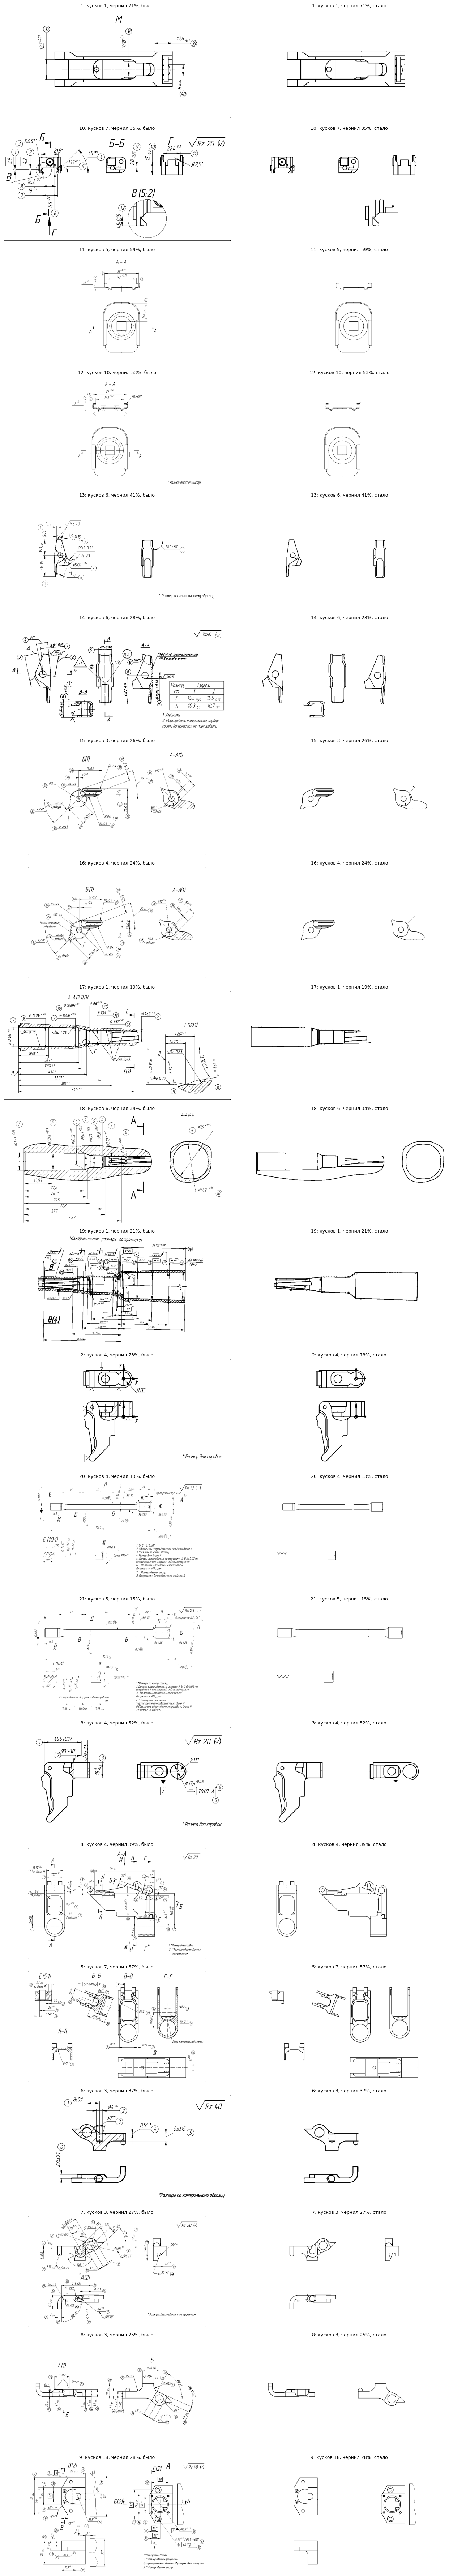

In [5]:
names = [row.name for row in rows]
show_before_after_list(
    [before_previews[name] for name in names],
    [after_previews[name] for name in names],
    [
        f"{name}: кусков {row.part_piece_count}, чернил {row.part_ink_share:.0%}"
        for name, row in zip(names, rows, strict=True)
    ],
)